In [ ]:
# Python 高性能表格数据处理与分析第三方库 常用于清洗、统计、运算结构化数据
import pandas as pd
# 数据分析、机器学习 计算库
import numpy as np
#  Python 绘图库  折线 等
import matplotlib.pyplot as plt
// 高级可视化库
import seaborn as sns
# 深色网格背景
sns.set_style('darkgrid')
# RdBu 红蓝渐变调色板
sns.set_palette("RdBu")

In [ ]:
# 读取 Excel 数据到 Python 支持格式多
data = pd.read_excel('./coffee_shop_sale.xlsx')

In [11]:
# 前 5 行样例数据
data.head()


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [ ]:
# 有多少行数据记录、有多少列字段
data.shape

(149116, 11)

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [15]:
data.duplicated().any()

False

In [ ]:
# 2. 数据预处理
# 计算每笔交易的销售额（销售数量 * 单品单价）
# 会在原数据中添加一个新列 sales_amount
data['sales_amount'] = data['transaction_qty'] * data['unit_price']
data

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,sales_amount
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.00
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.00
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.00
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20
...,...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,5.00
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,6.00
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,3.00
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino,3.75


In [ ]:
# 提取年月信息，格式为"YYYY-MM"，用于月度分组
data['year_month'] = data['transaction_date'].dt.to_period('M')
data

: 

In [ ]:
# 查看预处理结果（可选）
# 需要的数据
print("===== 预处理后数据样例 =====")
print(data[['transaction_date', 'year_month', 'transaction_qty', 'unit_price', 'sales_amount']].head())


===== 预处理后数据样例 =====
  transaction_date year_month  transaction_qty  unit_price  sales_amount
0       2023-01-01    2023-01                2         3.0           6.0
1       2023-01-01    2023-01                2         3.1           6.2
2       2023-01-01    2023-01                2         4.5           9.0
3       2023-01-01    2023-01                1         2.0           2.0
4       2023-01-01    2023-01                2         3.1           6.2


In [ ]:
# 3. 按月份汇总总销售额
# 按年月分组
# 对每组求和， 得到每月销售总额
# 将结果还原为普通 DataFrame
monthly_sales = data.groupby('year_month')['sales_amount'].sum().reset_index()
# 转换年月为字符串格式，避免绘图时的格式问题
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

: 

In [21]:
print("\n===== 月度销售额汇总结果 =====")
print(monthly_sales)


===== 月度销售额汇总结果 =====
  year_month  sales_amount
0    2023-01      81677.74
1    2023-02      76145.19
2    2023-03      98834.68
3    2023-04     118941.08
4    2023-05     156727.76
5    2023-06     166485.88


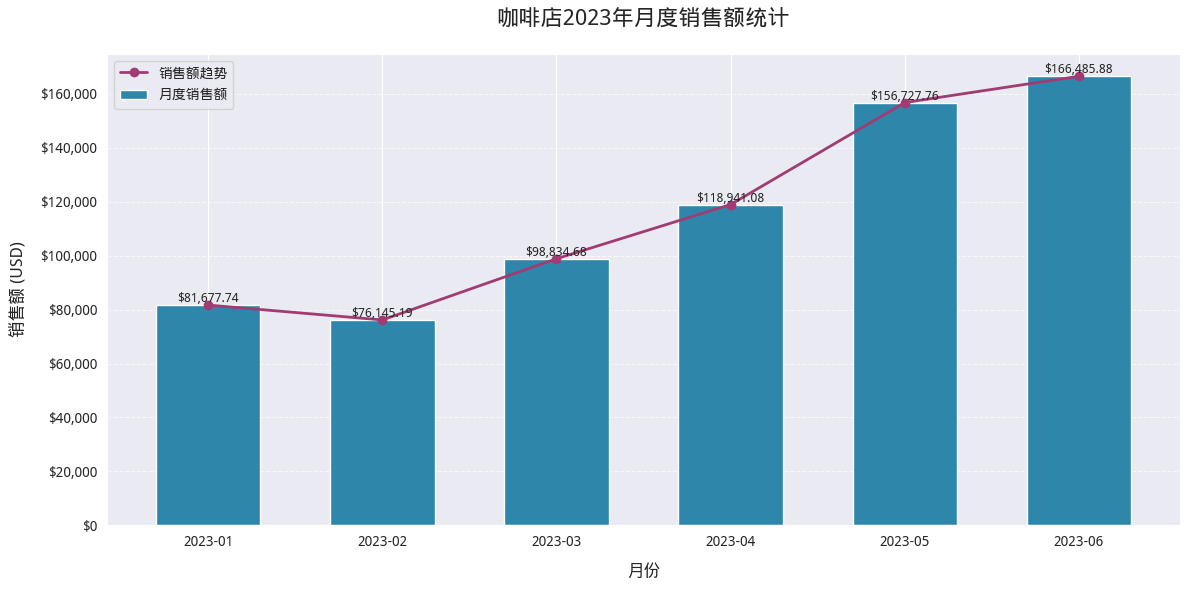

In [ ]:
# 设置中文字体，避免中文乱码（Windows/Mac/Linux 兼容）
plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False
# 创建一个宽 12 英寸、高 6 英寸、分辨率 100 dpi 的画布（即 1200×600 像素）
plt.figure(figsize=(12, 6), dpi=100)

# 绘制柱状图，展示各月销售额绝对值
bars = plt.bar(
    monthly_sales['year_month'], 
    monthly_sales['sales_amount'], 
    color='#2E86AB', 
    width=0.6, 
    label='月度销售额'
)

# 绘制折线图，展示销售额增长趋势
plt.plot(
    monthly_sales['year_month'], 
    monthly_sales['sales_amount'], 
    color='#A23B72', 
    marker='o', 
    linewidth=2, 
    label='销售额趋势'
)

# 在柱状图顶部添加具体销售额数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2., 
        height,
        f'${height:,.2f}',
        ha='center', 
        va='bottom', 
        fontsize=9
    )

# 图表样式美化
plt.title('咖啡店2023年月度销售额统计', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('月份', fontsize=12, labelpad=10)
plt.ylabel('销售额 (USD)', fontsize=12, labelpad=10)

# Y轴设置千分位货币格式，提升可读性
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))

# 添加横向网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 添加图例
plt.legend(fontsize=10)

# 自动调整布局，避免标签被截断
plt.tight_layout()

# 保存高清图表到本地
plt.savefig('咖啡店月度销售额统计.png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()